<a href="https://colab.research.google.com/github/maciejczek3324/pyton/blob/master/ESiwR%20Z3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install tensorflow

In [20]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras.datasets import mnist

from keras import models
from keras import layers

In [21]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [22]:
train_images.shape

(60000, 28, 28)

In [23]:
len(train_labels)

60000

In [24]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [25]:
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
network.compile(optimizer = 'rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

In [27]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28*28))
test_images = test_images.astype('float32') / 255

In [28]:
test_images[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [29]:
from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [30]:
test_labels[2]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [31]:
network.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9232 - loss: 0.2659
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9683 - loss: 0.1068
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9799 - loss: 0.0698
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9850 - loss: 0.0507
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9886 - loss: 0.0382


In [32]:
test_loss, test_acc = network.evaluate(test_images, test_labels)
print(f'test_acc: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0613
test_acc: 0.9810000061988831


In [33]:
import matplotlib.pyplot as plt
import numpy as np

In [34]:
indices = [1, 3, 2]

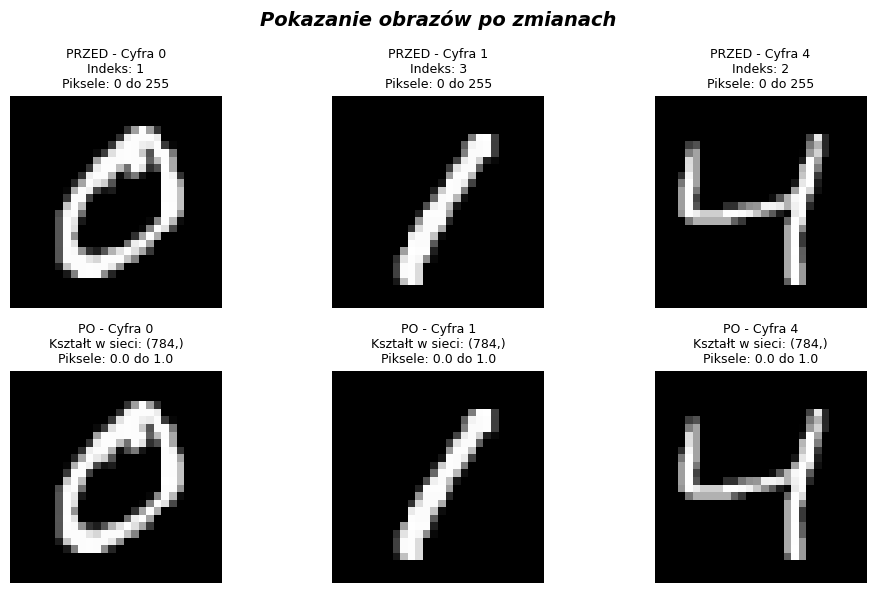

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle('Pokazanie obrazów po zmianach', fontsize=14, fontweight='bold', fontstyle='italic')

for i, idx in enumerate(indices):
    # Pobranie przetworzonego obrazu (wektor 784-elementowy, wartości 0.0 - 1.0)
    processed_img = train_images[idx]

    # Etykiety są w formacie one-hot (np. [0, 1, 0...]), więc używamy argmax, by wyciągnąć cyfrę
    label = np.argmax(train_labels[idx])

    # --- WERSJA "PRZED" ---
    # Odtwarzamy oryginalny wygląd: wracamy do wymiaru 28x28 i mnożymy przez 255
    img_before = (processed_img.reshape(28, 28) * 255).astype('uint8')

    ax_before = axes[0, i]
    ax_before.imshow(img_before, cmap='gray')
    ax_before.set_title(f"PRZED - Cyfra {label}\nIndeks: {idx}\nPiksele: 0 do 255", fontsize=9)
    ax_before.axis('off')

    # --- WERSJA "PO" ---
    # Do wyświetlenia musimy nadać wymiar 2D (28x28), choć w sieci jest to 1D (784,)
    img_after = processed_img.reshape(28, 28)

    # Wyciągamy rzeczywiste minimum i maksimum dla danego obrazka (zwykle bliskie 0.0 i 1.0)
    min_val = np.min(processed_img)
    max_val = np.max(processed_img)

    ax_after = axes[1, i]
    ax_after.imshow(img_after, cmap='gray')
    ax_after.set_title(f"PO - Cyfra {label}\nKształt w sieci: ({28 * 28},)\nPiksele: {min_val:.1f} do {max_val:.1f}", fontsize=9)
    ax_after.axis('off')

# Poprawia odstępy między wykresami
plt.tight_layout()
plt.show()

In [38]:
network.fit(train_images, train_labels, epochs=5, batch_size=128)
test_loss, test_acc = network.evaluate(test_images, test_labels)
print(f'test_acc: {test_acc}')

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9984 - loss: 0.0067
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9991 - loss: 0.0045
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9995 - loss: 0.0032
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9997 - loss: 0.0024
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9998 - loss: 0.0015
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0637
test_acc: 0.9825999736785889
